In [1]:
# Load libraries

%load_ext autoreload
%autoreload 2

import pandas as pd
print("success: pandas")
import numpy as np
print("success: numpy")
import matplotlib.pyplot as plt
print("success: matplotlib")
import sklearn as sk
print("success: sklearn")
import seaborn as sns
print("success: c'est bon")
from pathlib import Path
dataset_train_filepath = Path('.') / 'datasets' / 'train.csv'
DATA_TRAIN_MAIN = pd.read_csv(dataset_train_filepath)
df_train = DATA_TRAIN_MAIN.copy()

success: pandas
success: numpy
success: matplotlib
success: sklearn
success: c'est bon


In [2]:
import mlsnips as mu
df_train_columns = df_train.columns.to_list()
# len(df_train_columns)
mu.eda_inspect_df(df_train)

>>> Shape:  (1460, 81)
>>> Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    146

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [3]:
mu.eda_catcounts(df_train)

,column,category,count
0,MSZoning,RL,1151
1,MSZoning,RM,218
2,MSZoning,FV,65
3,MSZoning,RH,16
4,MSZoning,C (all),10
...,...,...,...
246,SaleCondition,Partial,125
247,SaleCondition,Abnorml,101
248,SaleCondition,Family,20
249,SaleCondition,Alloca,12


In [4]:
df_numerical = df_train.drop(columns=['Id']).select_dtypes(include=['float64', 'int64'])
df_numerical_columns = df_numerical.columns.to_list()
len(df_numerical_columns)

37

In [6]:
df_numerical_columns_nullcount = df_numerical.isna().sum().sort_values(ascending=False)
df_numerical_columns_nullcount.head()

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
MSSubClass       0
LotArea          0
dtype: int64

<Axes: >

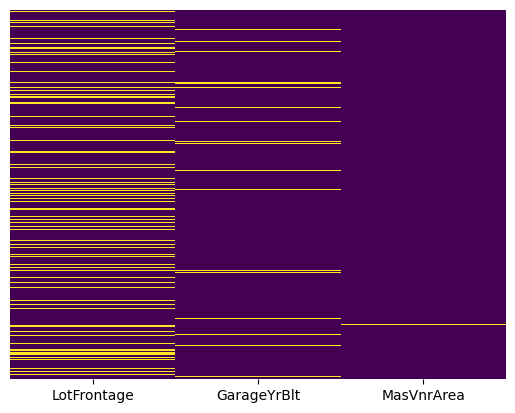

In [7]:
df_numerical_columns_with_nulls = [
    "LotFrontage",
    "GarageYrBlt",
    "MasVnrArea",
]
sns.heatmap(df_train[df_numerical_columns_with_nulls].isnull(),cmap='viridis',cbar=False,yticklabels=False)

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

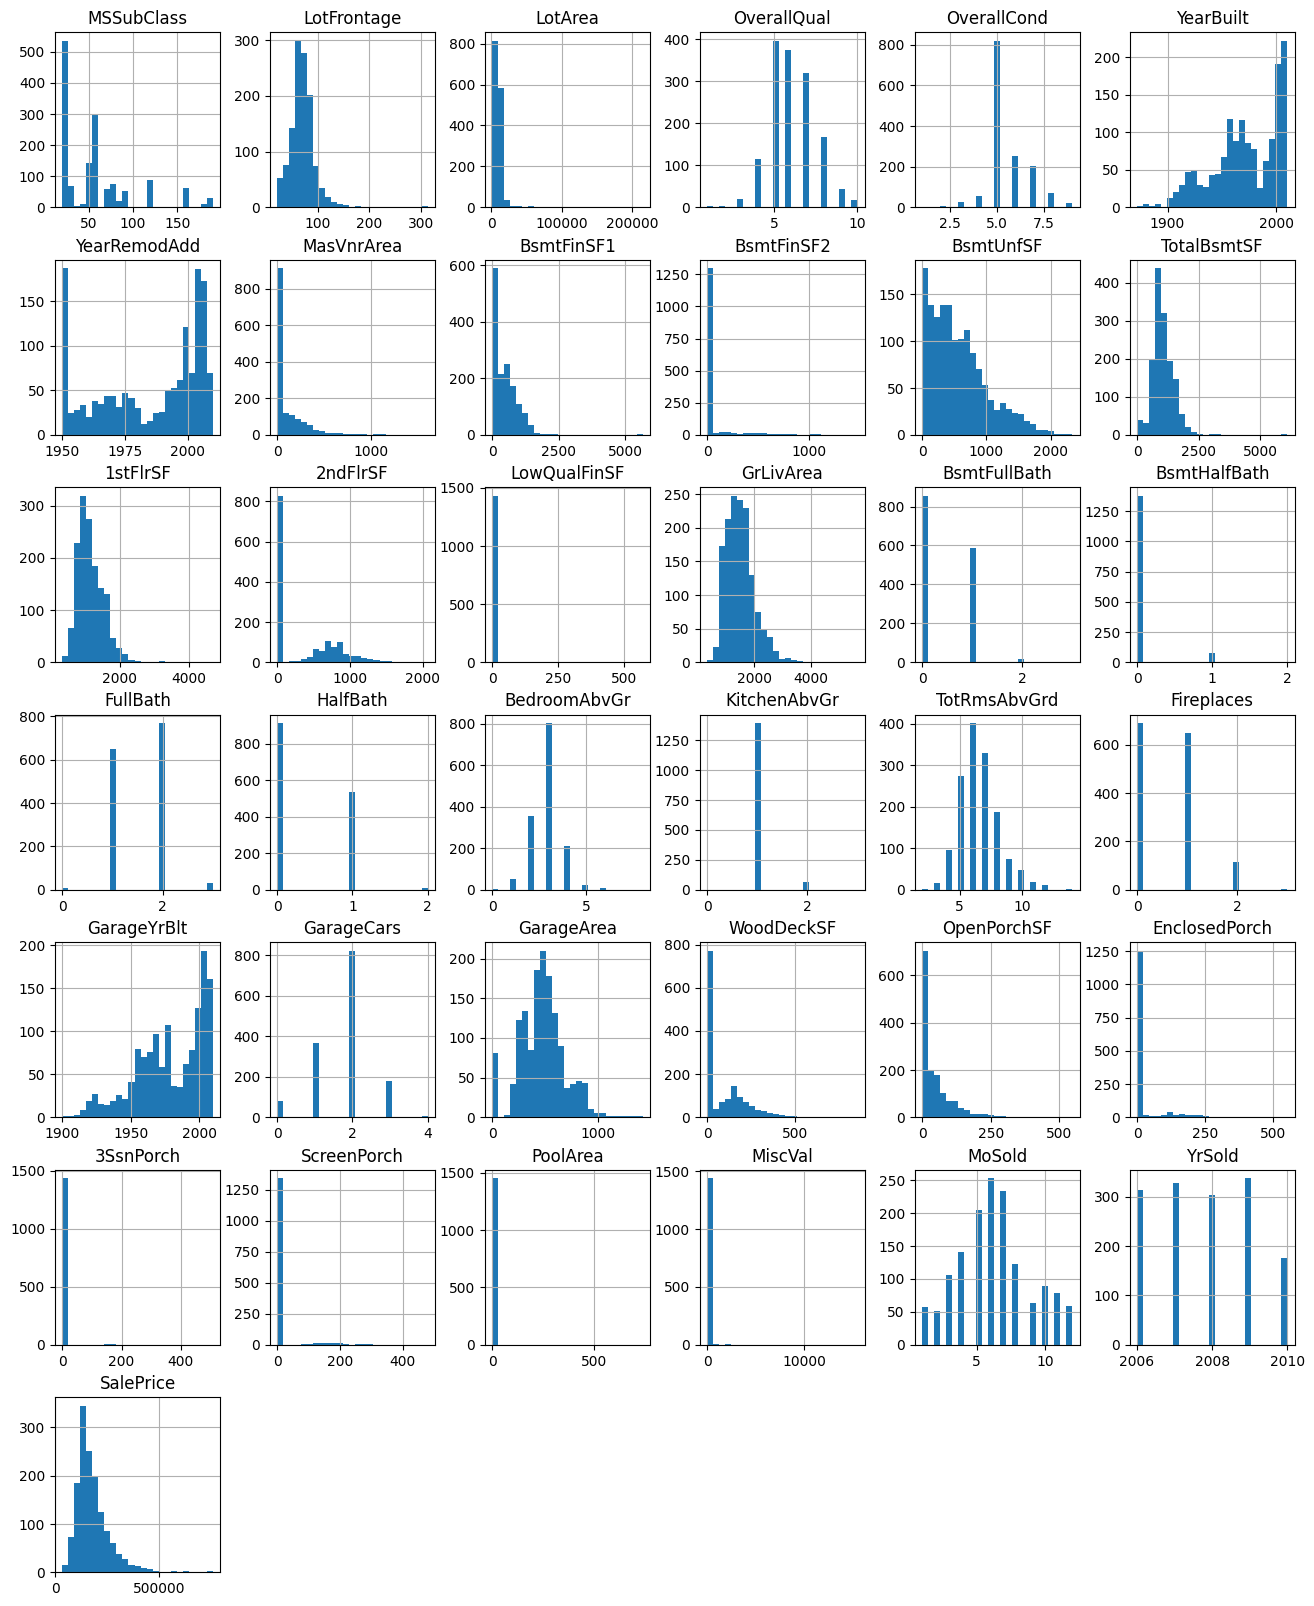

In [8]:
mu.graph_big_hist(df_train[df_numerical_columns])

In [9]:
df_nullcount = df_train.isna().sum().sort_values(ascending=False)
df_nullcount = df_nullcount[df_nullcount > 0]
df_nullcount.to_dict().keys()

dict_keys(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage', 'GarageQual', 'GarageFinish', 'GarageType', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType1', 'MasVnrArea', 'Electrical'])

<Axes: >

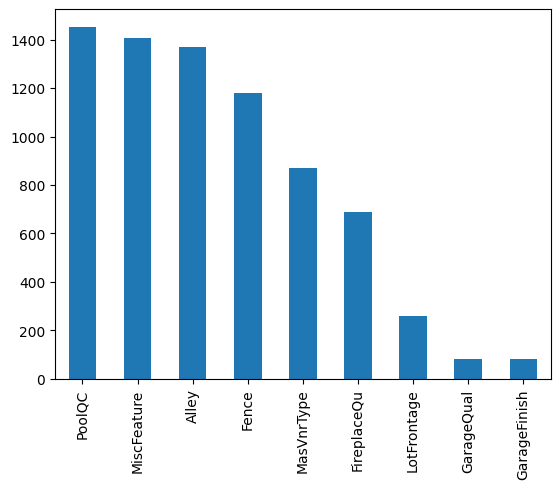

In [10]:
meaningful_nulls_cat = ['PoolQC','MiscFeature', 'Alley', 'Fence','FireplaceQu','MasVnrType']
meaningful_nulls_num = ['MasVnrArea']
error_nulls = ['LotFrontage']
df_nullcount.head(9).plot(kind="bar")

c:\Users\User\Documents\Code\python\ml\kaggle - housing prediction contest\mlsnips.py:78: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = values[i]


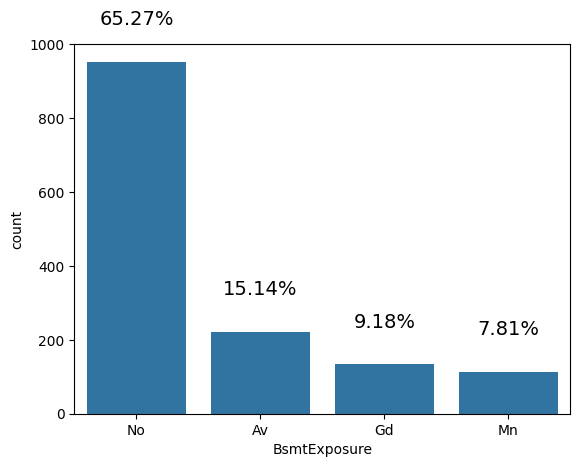

In [11]:
mu.graph_onecat_hist(df_train, "BsmtExposure")

Cleaning up meaningful majority nulls

In [12]:

# meaningful_nulls_cat = ['PoolQC','MiscFeature', 'Alley', 'Fence','FireplaceQu','MasVnrType']
# meaningful_nulls_num = ['MasVnrArea']
# error_nulls = ['LotFrontage']
df_train[meaningful_nulls_cat] = df_train[meaningful_nulls_cat].fillna('None')
df_train[meaningful_nulls_num] = df_train[meaningful_nulls_num].fillna(0) # quick patch
df_train['LotFrontage'] = df_train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median())) # oops